# (01) reproduce: (16, 20.0)

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Trainer

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16', 'grad|lin')

cfg_vae['seq_len'] = 64
cfg_tr['kl_beta'] = 64.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_vH16_t-64_z-[512]_u-10,du-10_<grad|lin>
b200-ep300-lr(0.005)_beta(64:0.1)_temp(0.01:0.5)_gr(500)_(2025_03_06,23:23)

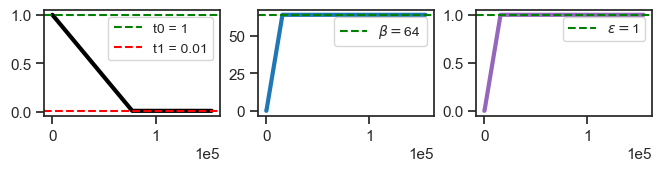

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
# cm = ''
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 300, avg loss: 184.947: 100%|█████| 300/300 [18:42:20<00:00, 224.47s/it]


In [6]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.1228], device='cuda:0', grad_fn=<ExpBackward0>),)

In [7]:
print(tr.model.layer.n_exp)

tensor([ 62,  74,  88, 103, 120, 139, 157, 173, 188, 199, 208, 215, 220, 223,
        226, 228, 229, 230, 230, 230, 231, 231, 231, 231, 231, 231, 231, 230,
        230, 230, 230, 230, 230, 230, 230, 229, 230, 230, 230, 230, 229, 229,
        229, 229, 229, 229, 229, 229, 228, 229, 229, 228, 228, 228, 228, 229,
        229, 229, 229, 229, 229, 229, 229, 229], device='cuda:0',
       dtype=torch.int32)

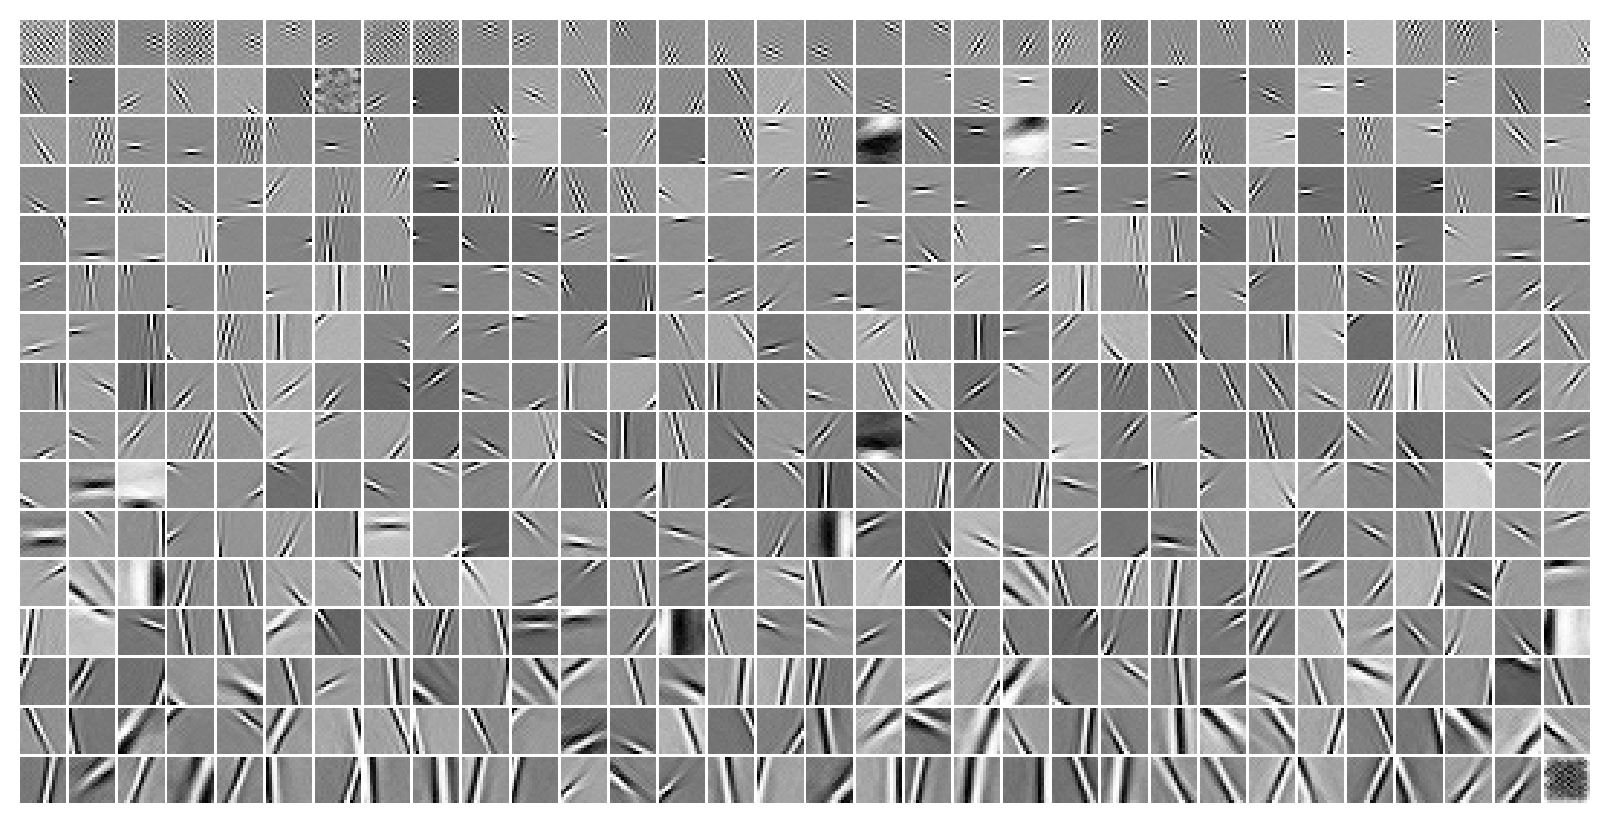

In [8]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

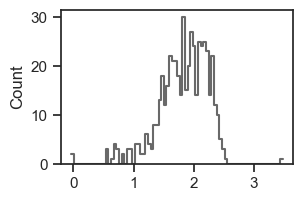

In [9]:
histplot(u0, bins=80, color='dimgrey')
plt.show()

In [10]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())

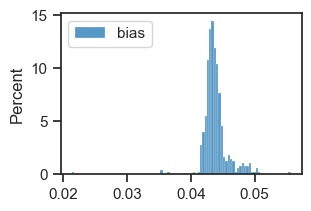

In [11]:
fig, ax = create_figure()

sns.histplot(bias, label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

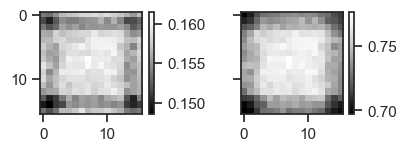

In [12]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_trn.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:40<00:00, 20.43s/it]


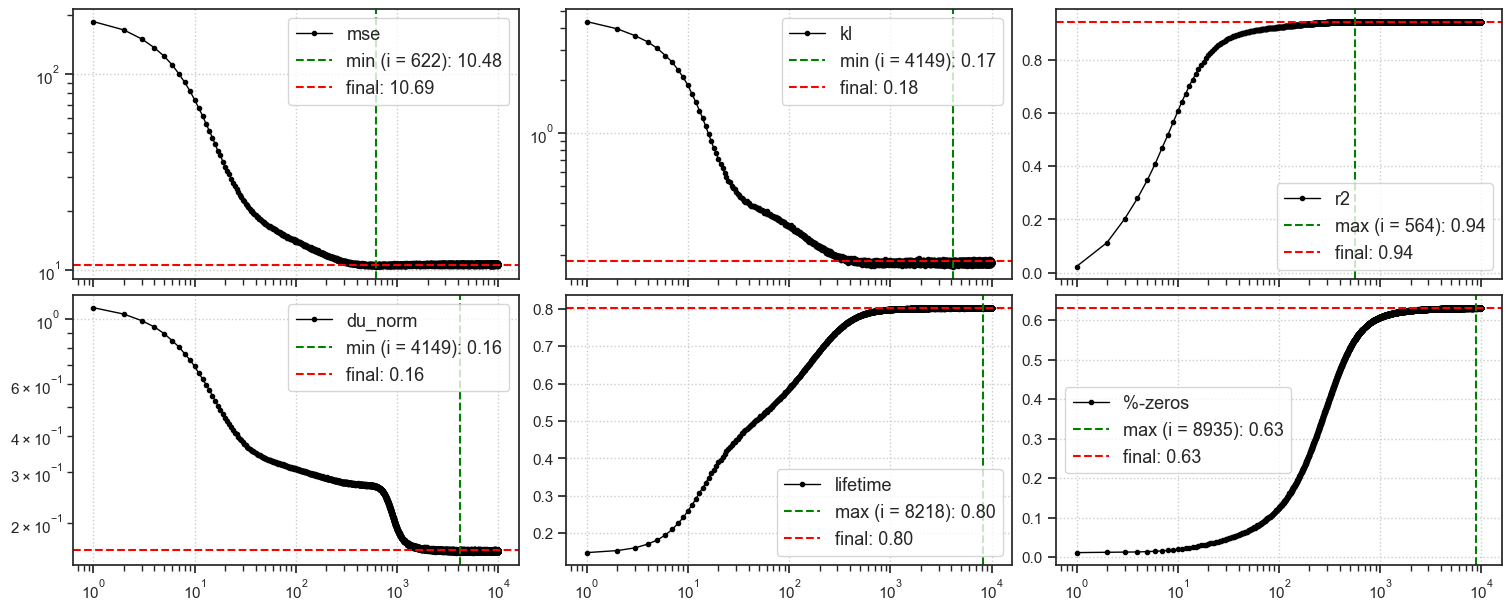

CPU times: user 49.7 s, sys: 3.39 s, total: 53.1 s
Wall time: 53.1 s


In [13]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')